# tstoolbox: Statistics
I will use the water level record for USGS site '02240000 OCKLAWAHA RIVER NEAR CONNER, FL'.  Use tsgettoolbox to download the data we will be using.

In [26]:
%matplotlib inline

In [27]:
# Third party imports
from plottoolbox import plottoolbox
from tsgettoolbox import tsgettoolbox

# First party imports
from tstoolbox import tstoolbox
from tstoolbox.toolbox_utils.src.toolbox_utils import tsutils

In [28]:
ock_flow = tsgettoolbox.wdfn_daily(
    monitoring_location_id="USGS-02240000",
    time="2008-01-01/2016-01-01",
    parameter_code="00060",
)

In [29]:
ock_flow.head()

,USGS-02240000_00060_00003:ft^3/s
Datetime,
2008-01-01,541
2008-01-02,533
2008-01-03,520
2008-01-04,508
2008-01-05,516


In [30]:
ock_stage = tsgettoolbox.wdfn_daily(
    monitoring_location_id="USGS-02240000",
    time="2008-01-01/2016-01-01",
    parameter_code="00065",
)

In [31]:
ock_stage.head()

,USGS-02240000_00065_00003:ft
Datetime,
2008-01-01,3.67
2008-01-02,3.64
2008-01-03,3.60
2008-01-04,3.58
2008-01-05,3.57


The tstoolbox.rolling_window calculates the average stage over the spans listed in the 'span' argument.

In [32]:
r_ock_stage = tstoolbox.rolling_window(
    input_ts=ock_stage, span=[1, 14, 30, 60, 90, 120, 180, 274, 365], statistic="mean"
)
a_ock_stage = tstoolbox.aggregate(
    input_ts=r_ock_stage,
    agg_interval=tsutils.pandas_offset_by_version("YE"),
    statistic="max",
)

In [33]:
a_ock_stage

,USGS-02240000_00065_00003:ft:rolling.1.mean_max,USGS-02240000_00065_00003.001:ft:rolling.14.mean_max,USGS-02240000_00065_00003.002:ft:rolling.30.mean_max,USGS-02240000_00065_00003.003:ft:rolling.60.mean_max,USGS-02240000_00065_00003.004:ft:rolling.90.mean_max,USGS-02240000_00065_00003.005:ft:rolling.120.mean_max,USGS-02240000_00065_00003.006:ft:rolling.180.mean_max,USGS-02240000_00065_00003.007:ft:rolling.274.mean_max,USGS-02240000_00065_00003.008:ft:rolling.365.mean_max
Datetime,,,,,,,,,
2008-12-31,7.73,6.055714,5.638667,4.383333,4.049444,3.958,3.985167,<NA>,<NA>
2009-12-31,5.29,4.949286,4.257667,4.179333,4.272222,4.154833,3.953389,<NA>,<NA>
2010-12-31,7.49,6.492857,5.919667,5.079167,4.78,4.788167,<NA>,<NA>,<NA>
2011-12-31,6.22,5.357143,5.227,5.189333,5.175444,5.147917,4.967722,4.632664,4.345315
2012-12-31,6.12,5.473571,5.334667,5.308,5.233444,5.122083,4.809944,4.554051,4.559014
2013-12-31,5.39,5.248571,5.083,4.775333,4.458444,4.19275,3.812833,3.41062,<NA>
2014-12-31,5.86,5.762857,5.704667,5.614333,5.510222,5.437917,5.213722,3.709526,3.379041
2015-12-31,6.85,5.256429,5.001333,4.884167,4.792333,4.882583,5.126222,5.06073,4.767342
2016-12-31,3.41,3.485,3.549667,3.667167,3.866889,<NA>,<NA>,<NA>,<NA>


In [34]:
q_max_avg_obs = tstoolbox.calculate_fdc(input_ts=a_ock_stage, sort_values="descending")

In [35]:
q_max_avg_obs

,USGS-02240000_00065_00003:ft:rolling.1.mean_max,USGS-02240000_00065_00003.001:ft:rolling.14.mean_max,USGS-02240000_00065_00003.002:ft:rolling.30.mean_max,USGS-02240000_00065_00003.003:ft:rolling.60.mean_max,USGS-02240000_00065_00003.004:ft:rolling.90.mean_max,USGS-02240000_00065_00003.005:ft:rolling.120.mean_max,USGS-02240000_00065_00003.006:ft:rolling.180.mean_max,USGS-02240000_00065_00003.007:ft:rolling.274.mean_max,USGS-02240000_00065_00003.008:ft:rolling.365.mean_max
Plotting_position,,,,,,,,,
10.000000,7.73,6.492857,5.919667,5.614333,5.510222,<NA>,<NA>,<NA>,<NA>
11.111111,<NA>,<NA>,<NA>,<NA>,<NA>,5.437917,<NA>,<NA>,<NA>
12.500000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,5.213722,<NA>,<NA>
16.666667,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,5.06073,<NA>
20.000000,7.49,6.055714,5.704667,5.308,5.233444,<NA>,<NA>,<NA>,4.767342
22.222222,<NA>,<NA>,<NA>,<NA>,<NA>,5.147917,<NA>,<NA>,<NA>
25.000000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,5.126222,<NA>,<NA>
30.000000,6.85,5.762857,5.638667,5.189333,5.175444,<NA>,<NA>,<NA>,<NA>
33.333333,<NA>,<NA>,<NA>,<NA>,<NA>,5.122083,<NA>,4.632664,<NA>


<module 'matplotlib.pyplot' from '/var/home/timcera/miniconda3/envs/default311/lib/python3.11/site-packages/matplotlib/pyplot.py'>

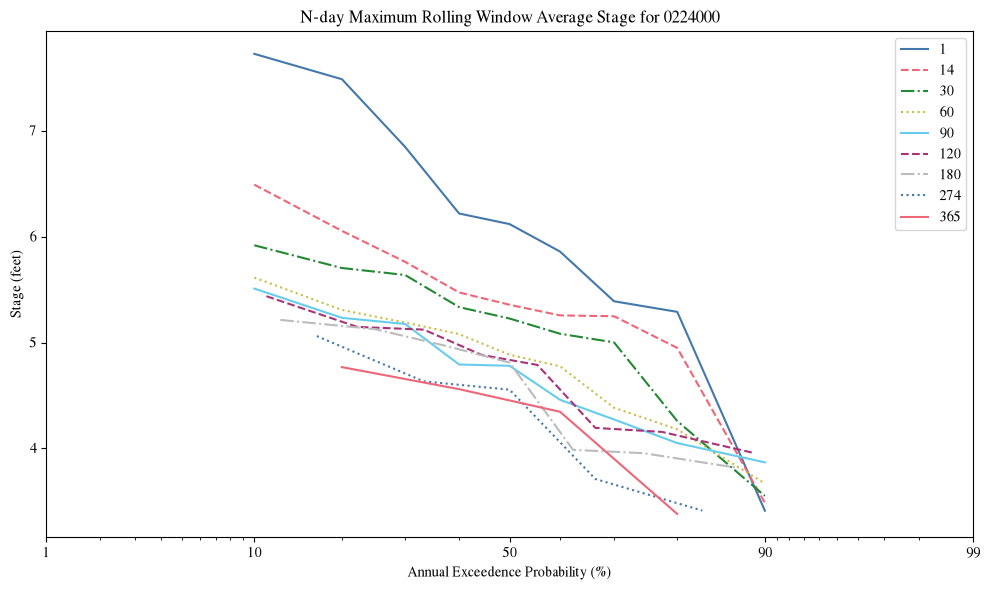

In [36]:
plottoolbox.norm_xaxis(
    input_ts=q_max_avg_obs,
    ofilename="q_max_avg.png",
    xtitle="Annual Exceedence Probability (%)",
    ytitle="Stage (feet)",
    title="N-day Maximum Rolling Window Average Stage for 0224000",
    legend_names=["1", "14", "30", "60", "90", "120", "180", "274", "365"],
)

In [37]:
combined = ock_flow.join(ock_stage)
combined.head()

,USGS-02240000_00060_00003:ft^3/s,USGS-02240000_00065_00003:ft
Datetime,,
2008-01-01,541,3.67
2008-01-02,533,3.64
2008-01-03,520,3.60
2008-01-04,508,3.58
2008-01-05,516,3.57


<module 'matplotlib.pyplot' from '/var/home/timcera/miniconda3/envs/default311/lib/python3.11/site-packages/matplotlib/pyplot.py'>

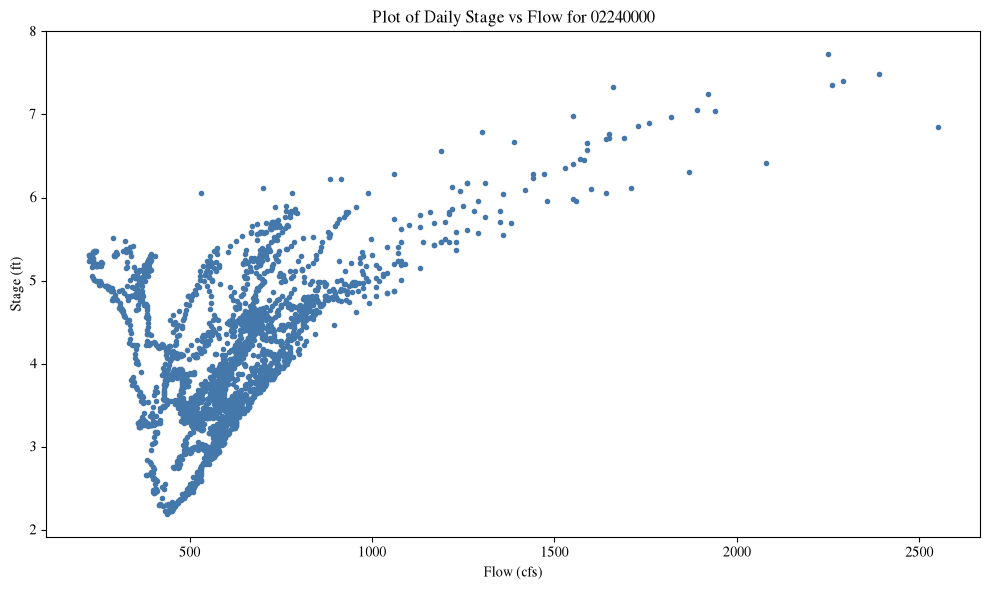

In [38]:
plottoolbox.xy(
    input_ts=combined,
    ofilename="stage_flow.png",
    legend=False,
    title="Plot of Daily Stage vs Flow for 02240000",
    xtitle="Flow (cfs)",
    ytitle="Stage (ft)",
    linestyles="",
    markerstyles=".",
)

Note the signficant impact of tail-water elevation.